Loading parquet files...
Merged rows: 59011, Hives: 26

MODALITY: TEMPERATURE
  Fixed-R KF wins:    10/26
  Adaptive-R wins:    16/26
  Ties:               0/26
  Fixed-R median RMSE:    2.8364
  Adaptive-R median RMSE: 2.8475


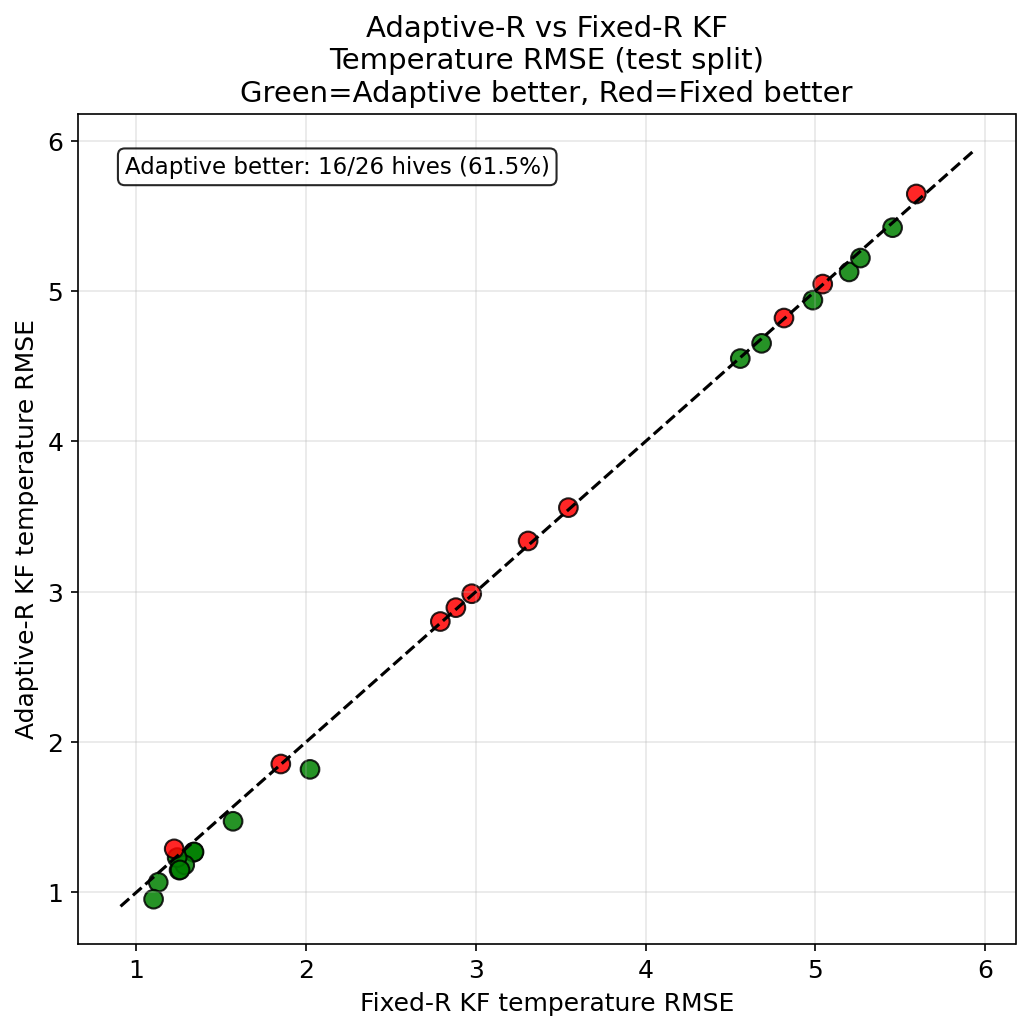

  Saved scatter: scatter_temperature_test.png


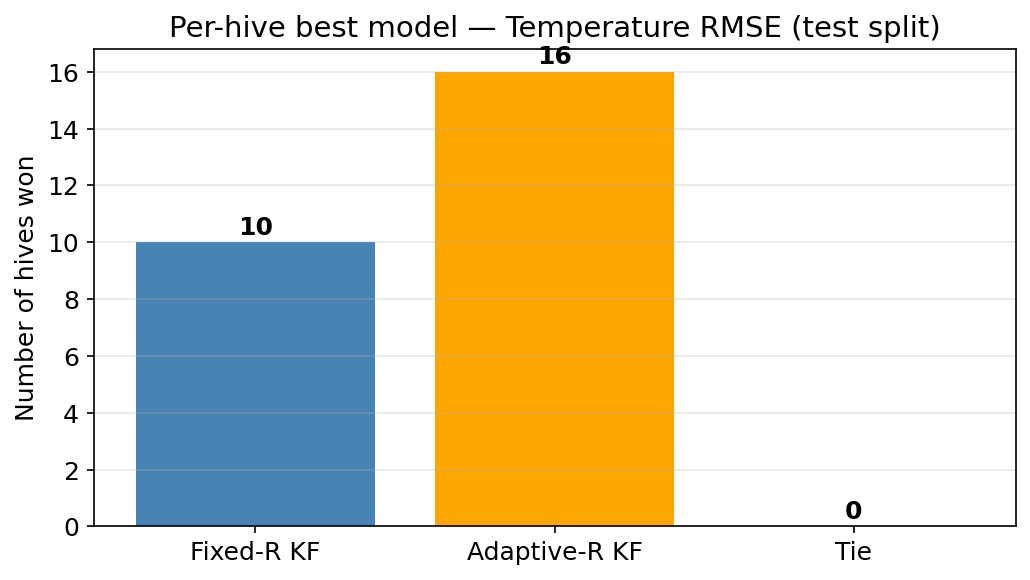

  Saved bar chart: wins_temperature_test.png

MODALITY: AUDIO_DENSITY
  Fixed-R KF wins:    24/26
  Adaptive-R wins:    2/26
  Ties:               0/26
  Fixed-R median RMSE:    7.1326
  Adaptive-R median RMSE: 7.2971


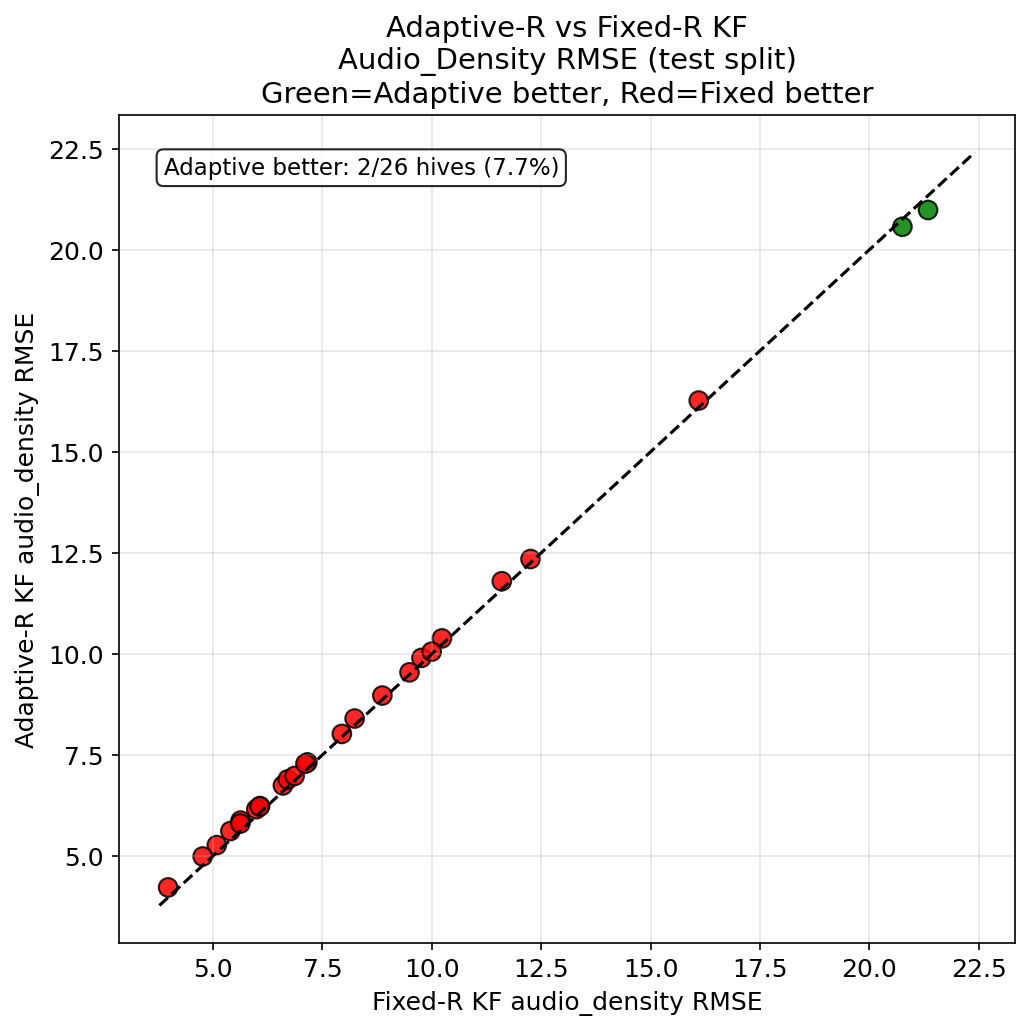

  Saved scatter: scatter_audio_density_test.png


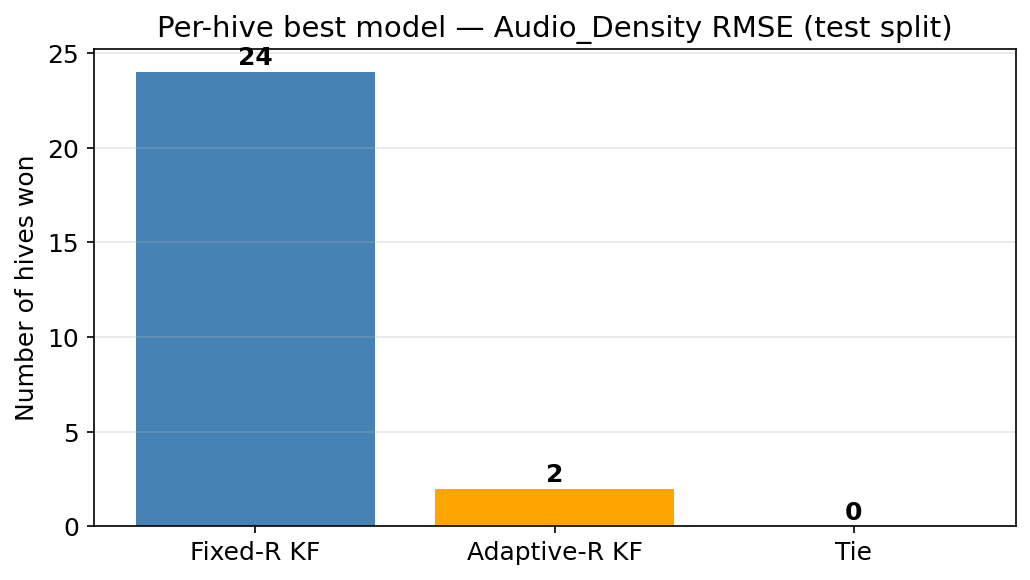

  Saved bar chart: wins_audio_density_test.png

SUMMARY ACROSS MODALITIES
     modality  fixed_wins  adapt_wins  ties  total_hives  fixed_median_rmse  adapt_median_rmse  adapt_pct_improvement
  temperature          10          16     0           26           2.836365           2.847478              -0.391786
audio_density          24           2     0           26           7.132586           7.297119              -2.306780

Saved summary: modality_summary_test.csv

DONE. Figures saved in: E:\testing\beetwin-prototype\backend\data\figures_modality_comparison


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)

# ============================================================
# EDIT ONLY THIS SECTION
# ============================================================
FIXED_DIR = Path("../backend/data/kf_outputs_syn")
ADAPT_DIR = Path("../backend/data/kf_outputs_experiment_adaptiveR_syn")

FIXED_TAG = "kf_fair_syn"
ADAPT_TAG = "adaptiveR_GATED_FAIR_SYN"

SPLIT = "test"

# *** CHANGE THIS TO RUN DIFFERENT MODALITIES ***
# Options: "temperature", "humidity", "audio_density"
MODALITIES = ["temperature", "audio_density"]  # runs both in one go

FIG_DIR = Path("../backend/data/figures_modality_comparison")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TIE_EPS = 1e-3

# ============================================================
# Load files
# ============================================================
fixed_path = FIXED_DIR / f"{FIXED_TAG}_val_test_forecast_nis.parquet"
adapt_path = ADAPT_DIR / f"kf_val_test_forecast_nis_{ADAPT_TAG}.parquet"

print("Loading parquet files...")
fixed = pd.read_parquet(fixed_path)
adapt = pd.read_parquet(adapt_path)

def clean_df(df):
    df = df.copy()
    df["published_at"] = pd.to_datetime(df["published_at"], utc=True, errors="coerce")
    df["hive_id"] = pd.to_numeric(df["hive_id"], errors="coerce").astype("Int64")
    df["split"] = df["split"].astype(str).str.strip().str.lower()
    df = df.dropna(subset=["published_at", "hive_id"])
    df = df[df["split"].isin(["val", "test"])].copy()
    return df.sort_values(["hive_id", "published_at"]).reset_index(drop=True)

fixed = clean_df(fixed)
adapt = clean_df(adapt)

# Merge all rows for selected split
merged_all = fixed.merge(
    adapt,
    on=["published_at", "hive_id", "split"],
    how="inner",
    suffixes=("_fixed", "_adapt")
)
merged_all = merged_all[merged_all["split"] == SPLIT].copy()
print(f"Merged rows: {len(merged_all)}, Hives: {merged_all['hive_id'].nunique()}")

# ============================================================
# Run analysis per modality
# ============================================================
summary_rows = []

for MODALITY in MODALITIES:
    print(f"\n{'='*50}")
    print(f"MODALITY: {MODALITY.upper()}")
    print(f"{'='*50}")

    true_col  = f"y_true_{MODALITY}_fixed"
    fixed_col = f"y_pred_{MODALITY}_fixed"
    adapt_col = f"y_pred_{MODALITY}_adapt"

    # Check columns exist
    missing = [c for c in [true_col, fixed_col, adapt_col] if c not in merged_all.columns]
    if missing:
        print(f"  Missing columns: {missing} — skipping")
        continue

    # Per-hive RMSE
    rows = []
    for hive_id, g in merged_all.groupby("hive_id"):
        y_true = g[true_col].to_numpy(float)
        y_fix  = g[fixed_col].to_numpy(float)
        y_adp  = g[adapt_col].to_numpy(float)

        mask_f = np.isfinite(y_true) & np.isfinite(y_fix)
        mask_a = np.isfinite(y_true) & np.isfinite(y_adp)

        if mask_f.sum() < 20 or mask_a.sum() < 20:
            continue

        rmse_fix = float(np.sqrt(np.mean((y_true[mask_f] - y_fix[mask_f])**2)))
        rmse_adp = float(np.sqrt(np.mean((y_true[mask_a] - y_adp[mask_a])**2)))
        rows.append((int(hive_id), rmse_fix, rmse_adp))

    df_sc = pd.DataFrame(rows, columns=["hive_id", "rmse_fixed", "rmse_adapt"]).dropna()

    if len(df_sc) == 0:
        print("  No valid hives — skipping")
        continue

    # Win counts
    fixed_wins = int((df_sc["rmse_fixed"] + TIE_EPS < df_sc["rmse_adapt"]).sum())
    adapt_wins = int((df_sc["rmse_adapt"] + TIE_EPS < df_sc["rmse_fixed"]).sum())
    ties       = int(len(df_sc) - fixed_wins - adapt_wins)
    total      = len(df_sc)

    print(f"  Fixed-R KF wins:    {fixed_wins}/{total}")
    print(f"  Adaptive-R wins:    {adapt_wins}/{total}")
    print(f"  Ties:               {ties}/{total}")
    print(f"  Fixed-R median RMSE:    {df_sc['rmse_fixed'].median():.4f}")
    print(f"  Adaptive-R median RMSE: {df_sc['rmse_adapt'].median():.4f}")

    summary_rows.append({
        "modality": MODALITY,
        "fixed_wins": fixed_wins,
        "adapt_wins": adapt_wins,
        "ties": ties,
        "total_hives": total,
        "fixed_median_rmse": df_sc["rmse_fixed"].median(),
        "adapt_median_rmse": df_sc["rmse_adapt"].median(),
        "adapt_pct_improvement": 100*(df_sc["rmse_fixed"].median() - df_sc["rmse_adapt"].median()) / df_sc["rmse_fixed"].median()
    })

    # ---- Fig A: Colored scatter ----
    colors = []
    for _, r in df_sc.iterrows():
        diff = r["rmse_fixed"] - r["rmse_adapt"]
        if diff > TIE_EPS:
            colors.append("green")
        elif diff < -TIE_EPS:
            colors.append("red")
        else:
            colors.append("gray")

    plt.figure(figsize=(7, 7))
    plt.scatter(df_sc["rmse_fixed"], df_sc["rmse_adapt"],
                c=colors, s=80, alpha=0.85, edgecolor="black")
    mn = min(df_sc["rmse_fixed"].min(), df_sc["rmse_adapt"].min()) * 0.95
    mx = max(df_sc["rmse_fixed"].max(), df_sc["rmse_adapt"].max()) * 1.05
    plt.plot([mn, mx], [mn, mx], "k--", lw=1.5)
    plt.xlabel(f"Fixed-R KF {MODALITY} RMSE")
    plt.ylabel(f"Adaptive-R KF {MODALITY} RMSE")
    plt.title(f"Adaptive-R vs Fixed-R KF\n{MODALITY.title()} RMSE ({SPLIT} split)\nGreen=Adaptive better, Red=Fixed better")
    plt.text(0.05, 0.95,
             f"Adaptive better: {adapt_wins}/{total} hives ({100*adapt_wins/total:.1f}%)",
             transform=plt.gca().transAxes, fontsize=11, va="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"scatter_{MODALITY}_{SPLIT}.png", dpi=150, bbox_inches="tight")
    plt.savefig(FIG_DIR / f"scatter_{MODALITY}_{SPLIT}.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"  Saved scatter: scatter_{MODALITY}_{SPLIT}.png")

    # ---- Fig B: Bar chart win count ----
    plt.figure(figsize=(7, 4))
    bars = plt.bar(["Fixed-R KF", "Adaptive-R KF", "Tie"],
                   [fixed_wins, adapt_wins, ties],
                   color=["steelblue", "orange", "gray"])
    for bar, val in zip(bars, [fixed_wins, adapt_wins, ties]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(val), ha="center", va="bottom", fontsize=12, fontweight="bold")
    plt.ylabel("Number of hives won")
    plt.title(f"Per-hive best model — {MODALITY.title()} RMSE ({SPLIT} split)")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"wins_{MODALITY}_{SPLIT}.png", dpi=150, bbox_inches="tight")
    plt.savefig(FIG_DIR / f"wins_{MODALITY}_{SPLIT}.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"  Saved bar chart: wins_{MODALITY}_{SPLIT}.png")

    df_sc.to_csv(FIG_DIR / f"rmse_per_hive_{MODALITY}_{SPLIT}.csv", index=False)

# ============================================================
# Summary table across modalities
# ============================================================
if summary_rows:
    print("\n" + "="*60)
    print("SUMMARY ACROSS MODALITIES")
    print("="*60)
    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.to_string(index=False))
    summary_df.to_csv(FIG_DIR / f"modality_summary_{SPLIT}.csv", index=False)
    print(f"\nSaved summary: modality_summary_{SPLIT}.csv")

print("\nDONE. Figures saved in:", FIG_DIR.resolve())